In [ ]:
# TAREA 4 - ANÁLISIS DE IMÁGENES
'''
Siguiendo con el ejemplo visto en clase de monedas, aqu[i opté por
tomar una imagen de un grupo de tazos
'''

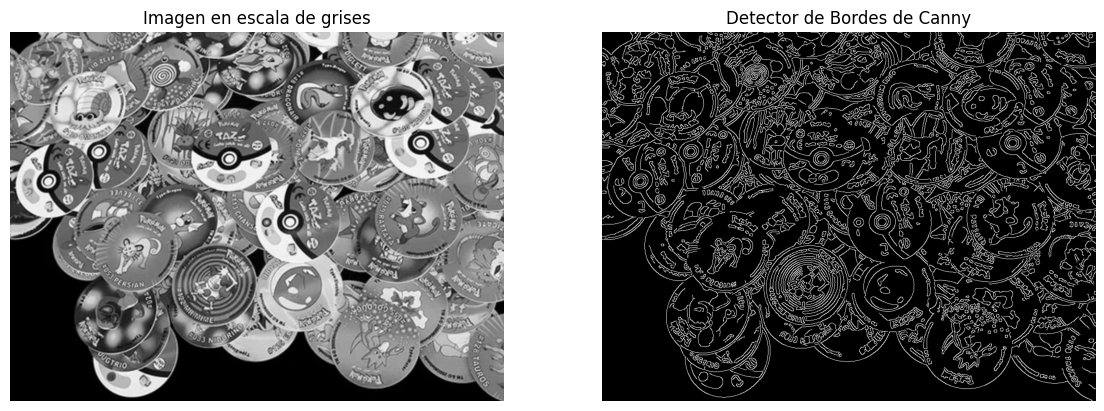

In [3]:
#Bordes de Canny
import cv2
import matplotlib.pyplot as plt

# Leer imagen
img = cv2.imread("tazos-pokemon.jpg")

# Escala de grises
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Suavizado
blur = cv2.GaussianBlur(gray, (5,5), 1.5)

# Detector de Canny
edges = cv2.Canny(blur, threshold1=50, threshold2=150)

# Mostrar resultados
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Imagen en escala de grises")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Detector de Bordes de Canny")
plt.axis("off")

plt.show()

Número de tazos detectados: 157


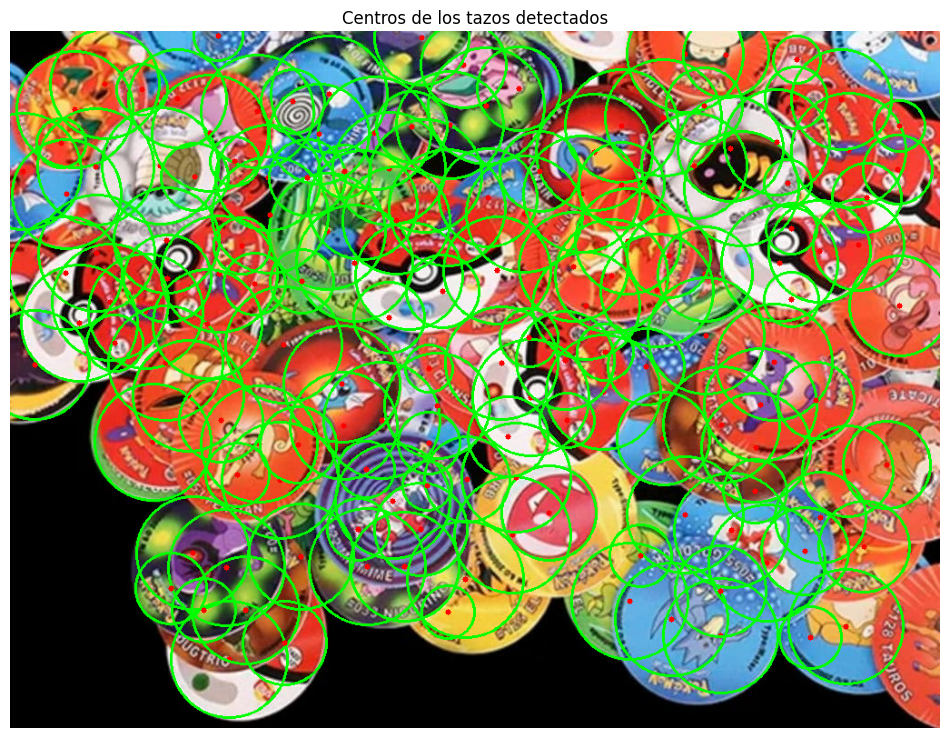

In [5]:
# Detector de los círculos por Hough

# Convertir de BGR a RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Escala de grises
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Suavizar ruido
gray = cv2.GaussianBlur(gray,(9,9),2)

# Detectar círculos
circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=40,
    param1=100,
    param2=28,
    minRadius=25,
    maxRadius=65
)

resultado = img_rgb.copy()

# Dibujar círculos y centros
if circles is not None:
    circles = np.round(circles[0]).astype(int)

    print("Número de tazos detectados:", len(circles))

    for (x,y,r) in circles:

        # Circunferencia
        cv2.circle(resultado,(x,y),r,(0,255,0),2)

        # Centro
        cv2.circle(resultado,(x,y),3,(255,0,0),-1)

plt.figure(figsize=(12,12))
plt.imshow(resultado)
plt.axis("off")
plt.title("Centros de los tazos detectados")
plt.show()

In [2]:
# Coordenadas de cada centro
for i,(x,y,r) in enumerate(circles):
    print(f"Tazo {i+1}: Centro=({x},{y})  Radio={r}")

Tazo 1: Centro=(421,517)  Radio=63
Tazo 2: Centro=(793,129)  Radio=58
Tazo 3: Centro=(593,530)  Radio=52
Tazo 4: Centro=(76,321)  Radio=64
Tazo 5: Centro=(524,82)  Radio=64
Tazo 6: Centro=(71,86)  Radio=64
Tazo 7: Centro=(457,159)  Radio=62
Tazo 8: Centro=(351,69)  Radio=64
Tazo 9: Centro=(230,267)  Radio=64
Tazo 10: Centro=(401,112)  Radio=62
Tazo 11: Centro=(95,244)  Radio=64
Tazo 12: Centro=(439,269)  Radio=59
Tazo 13: Centro=(165,148)  Radio=64
Tazo 14: Centro=(349,220)  Radio=64
Tazo 15: Centro=(365,388)  Radio=64
Tazo 16: Centro=(393,589)  Radio=64
Tazo 17: Centro=(662,269)  Radio=62
Tazo 18: Centro=(110,298)  Radio=64
Tazo 19: Centro=(501,603)  Radio=64
Tazo 20: Centro=(340,113)  Radio=55
Tazo 21: Centro=(409,428)  Radio=64
Tazo 22: Centro=(388,191)  Radio=60
Tazo 23: Centro=(680,231)  Radio=58
Tazo 24: Centro=(434,589)  Radio=60
Tazo 25: Centro=(238,590)  Radio=64
Tazo 26: Centro=(379,255)  Radio=64
Tazo 27: Centro=(643,133)  Radio=64
Tazo 28: Centro=(286,202)  Radio=64
Tazo 29

Se detectaron 157 tazos.


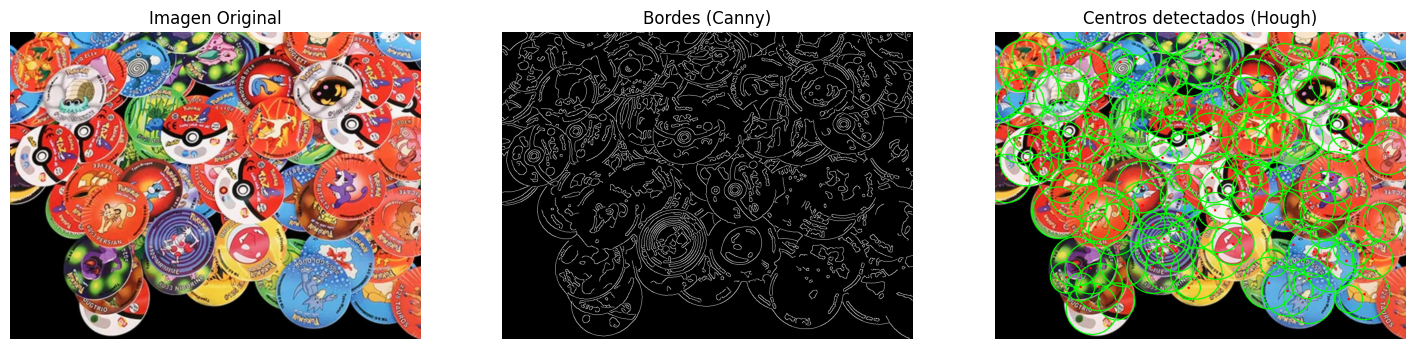

In [6]:
# Comparativa
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Escala de grises
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Suavizado
blur = cv2.GaussianBlur(gray, (9,9), 2)

# Canny (solo para visualizar)
edges = cv2.Canny(blur, 50, 150)

# Transformada de Hough
circles = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=40,
    param1=100,
    param2=28,
    minRadius=25,
    maxRadius=65
)

resultado = img_rgb.copy()

if circles is not None:
    circles = np.round(circles[0]).astype(int)

    for (x, y, r) in circles:
        # Circunferencia
        cv2.circle(resultado, (x, y), r, (0,255,0), 2)

        # Centro
        cv2.circle(resultado, (x, y), 3, (255,0,0), -1)

print(f"Se detectaron {len(circles)} tazos.")

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(edges, cmap='gray')
plt.title("Bordes (Canny)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(resultado)
plt.title("Centros detectados (Hough)")
plt.axis("off")

plt.show()